In [314]:
import pandas as pd
import numpy as np
import re
import pycountry
import matplotlib.pyplot as plt
import seaborn as sns

# import the data file
df_Data = pd.read_excel(
    r"D:\Projects\Data\Countries_Socioeconom_Profiles_Data\World_Development_Indicators.xlsx",
    sheet_name=0
)

# replace .. with nans
df_Data = df_Data.replace("..", np.nan)

# drop years with high persentage of nans
df_Data = df_Data.drop(columns=['2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]', '2025 [YR2025]'])

# Year columns
year_cols = [f"{year} [YR{year}]" for year in range(2010, 2022)]

df_Data = df_Data.melt(
    id_vars=["Country Name", "Country Code", "Series Name", "Series Code"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Value"
)

# Extract only the year
df_Data["Year"] = df_Data["Year"].str.extract(r"(\d{4})").astype(int)

# Make values numeric
df_Data["Value"] = pd.to_numeric(df_Data["Value"], errors="coerce")

# pivot df_Data
df_wide = df_Data.pivot(
    index=["Country Name", "Country Code", "Year"],
    columns="Series Name",
    values="Value"
).reset_index()

# normalize the names
df_wide.columns = (
    df_wide.columns
    .str.lower()
    .str.strip()
    .str.replace(r"[^\w\s]", "", regex=True)
    .str.replace(r"\s+", "_", regex=True)
)

rename_dict = {
    "Country Name": "country_name",
    "Country Code": "country_code",
    "Year": "year",
    
    "Access to electricity (% of population)": "access_to_electricity",
    "Agriculture, forestry, and fishing, value added (% of GDP)": "agriculture_value_added",
    "Broad money (% of GDP)": "broad_money",
    "Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)": "co2_emissions_per_capita",
    "Carbon intensity of GDP (kg CO2e per constant 2015 US$ of GDP)": "carbon_intensity_gdp",
    "Central government debt, total (% of GDP)": "government_debt",
    "Current health expenditure (% of GDP)": "health_expenditure",
    "Domestic credit to private sector (% of GDP)": "domestic_credit_private_sector",
    "Energy use (kg of oil equivalent per capita)": "energy_use_per_capita",
    "Exports of goods and services (% of GDP)": "exports",
    "Fertility rate, total (births per woman)": "fertility_rate",
    "Foreign direct investment, net inflows (% of GDP)": "fdi_inflows",
    "Forest area (% of land area)": "forest_area",
    "Fossil fuel energy consumption (% of total)": "fossil_fuel_consumption",
    "GDP growth (annual %)": "gdp_growth",
    "GDP per capita (constant 2015 US$)": "gdp_per_capita",
    "Gross capital formation (% of GDP)": "gross_capital_formation",
    "Imports of goods and services (% of GDP)": "imports",
    "Individuals using the Internet (% of population)": "internet_usage",
    "Industry (including construction), value added (% of GDP)": "industry_value_added",
    "Inflation, consumer prices (annual %)": "inflation",
    "Life expectancy at birth, total (years)": "life_expectancy",
    "Literacy rate, adult total (% of people ages 15 and above)": "literacy_rate",
    "Military expenditure (% of general government expenditure)": "military_expenditure",
    "Multidimensional poverty headcount ratio (World Bank) (% of population)": "multidimensional_poverty",
    "Population growth (annual %)": "population_growth",
    "Renewable electricity output (% of total electricity output)": "renewable_electricity",
    "Renewable energy consumption (% of total final energy consumption)": "renewable_energy",
    "Research and development expenditure (% of GDP)": "rd_expenditure",
    "School enrollment, primary (% gross)": "primary_school_enrollment",
    "Services, value added (% of GDP)": "services_value_added",
    "Trade (% of GDP)": "trade",
    "Unemployment, total (% of total labor force) (modeled ILO estimate)": "unemployment",
    "Urban population (% of total population)": "urban_population"
}

df_wide = df_wide.rename(columns=rename_dict)

# Retain only actual countries with valid ISO 3166-1 alpha-3 codes
valid_iso_codes = {country.alpha_3 for country in pycountry.countries}
df_countries = df_wide[df_wide['country_code'].isin(valid_iso_codes)].copy()

# calculate each country's overall percentage of missing data across all indicators and orders them from highest missingness to lowest.
feature_cols = df_countries.columns.difference(
    ["country_name", "country_code", "year"]
)

df_country_nan = (
    df_countries.groupby(["country_name", "country_code"])[feature_cols]
    .apply(lambda x: x.isna().sum().sum())
    .rename("nan_count")
    .reset_index()
)

# Total possible values per country
df_country_nan["total_values"] = (
    df_countries.groupby(["country_name", "country_code"])
    .size()
    .values * len(feature_cols)
)

# Percentage of missing values
df_country_nan["nan_percentage"] = (
    df_country_nan["nan_count"] /
    df_country_nan["total_values"]
)

df_country_nan = df_country_nan.sort_values(
    "nan_percentage",
    ascending=False
)

# delete country's with high persentage of nans
nan_per_delete = df_country_nan['nan_percentage'].quantile(q= 0.95)
country_to_delete = df_country_nan[df_country_nan['nan_percentage'] >= nan_per_delete]
country_to_delete_list = country_to_delete['country_name'].tolist()



# delete columns with high nans
nan_summary = (
    pd.DataFrame({
        "nan_count": df_countries.isna().sum(),
        "nan_percentage": df_countries.isna().mean()
    })
    .reset_index(names="Series Name")
    .sort_values("nan_percentage", ascending=False)
)

for country in country_to_delete_list:

    df_countries = df_countries[df_countries['country_name'] != country]

null_per_max = 0.5

Series_Name_delete = nan_summary[nan_summary['nan_percentage'] >= null_per_max]
Series_Name_delete_list = Series_Name_delete['Series Name'].tolist()
df_countries = df_countries.drop(columns=Series_Name_delete_list)

In [315]:
df_describe = df_countries.loc[:, 'access_to_electricity_of_population':'urban_population_of_total_population'].describe()
df_describe

Series Name,access_to_electricity_of_population,agriculture_forestry_and_fishing_value_added_of_gdp,broad_money_of_gdp,carbon_dioxide_co2_emissions_excluding_lulucf_per_capita_t_co2ecapita,carbon_intensity_of_gdp_kg_co2e_per_constant_2015_us_of_gdp,current_health_expenditure_of_gdp,domestic_credit_to_private_sector_of_gdp,energy_use_kg_of_oil_equivalent_per_capita,exports_of_goods_and_services_of_gdp,fertility_rate_total_births_per_woman,...,life_expectancy_at_birth_total_years,military_expenditure_of_general_government_expenditure,population_growth_annual_,renewable_electricity_output_of_total_electricity_output,renewable_energy_consumption_of_total_final_energy_consumption,school_enrollment_primary_gross,services_value_added_of_gdp,trade_of_gdp,unemployment_total_of_total_labor_force_modeled_ilo_estimate,urban_population_of_total_population
count,2448.000000,2343.000000,1833.000000,2364.000000,2337.000000,2261.000000,2050.000000,1762.000000,2154.000000,2448.000000,...,2448.000000,1770.000000,2448.000000,2355.000000,2434.000000,1958.000000,2355.000000,2154.000000,2220.000000,2448.000000
mean,83.182271,10.275560,96.453762,4.925511,0.480363,6.433767,53.554197,2420.141383,42.500311,2.720975,...,71.663812,6.664088,1.239710,31.845678,30.075267,102.183622,56.569801,90.515844,8.065983,60.053751
std,27.040945,9.964026,657.815293,9.130778,0.626112,2.783354,44.158189,2919.671790,32.278954,1.387199,...,8.212990,5.655858,1.536916,31.452776,28.435226,12.463327,12.585746,58.460714,6.028689,23.435335
min,1.500000,0.000000,8.585482,0.000000,0.000000,1.543096,0.497601,59.274917,0.000000,0.756000,...,31.530000,0.002831,-10.927442,0.000000,0.000000,25.565756,0.000000,0.000000,0.100000,10.984310
25%,73.650000,2.121586,33.453007,0.644550,0.194755,4.327758,21.072811,577.336491,22.237525,1.640000,...,65.894500,2.901329,0.263657,4.428475,6.200000,97.295790,48.470459,54.604223,3.819750,40.138737
50%,99.500000,6.738947,52.036082,2.477361,0.327230,6.034256,42.086882,1441.102301,34.789921,2.200000,...,72.887500,4.956930,1.179721,20.069733,20.900000,101.074576,55.745859,77.571275,6.077000,62.049210
75%,100.000000,16.561824,76.761272,6.029765,0.560835,8.300918,69.177067,2882.614759,52.629901,3.522500,...,77.741250,8.703266,2.203340,57.172368,48.375000,106.897667,65.047471,107.821133,11.063750,78.763737
max,100.000000,44.330943,13309.489839,202.865184,14.196519,22.113224,269.837325,21456.066928,340.303102,7.640000,...,85.532683,40.640081,14.225399,100.000000,97.000000,183.989440,96.162595,679.232773,34.153000,100.000000


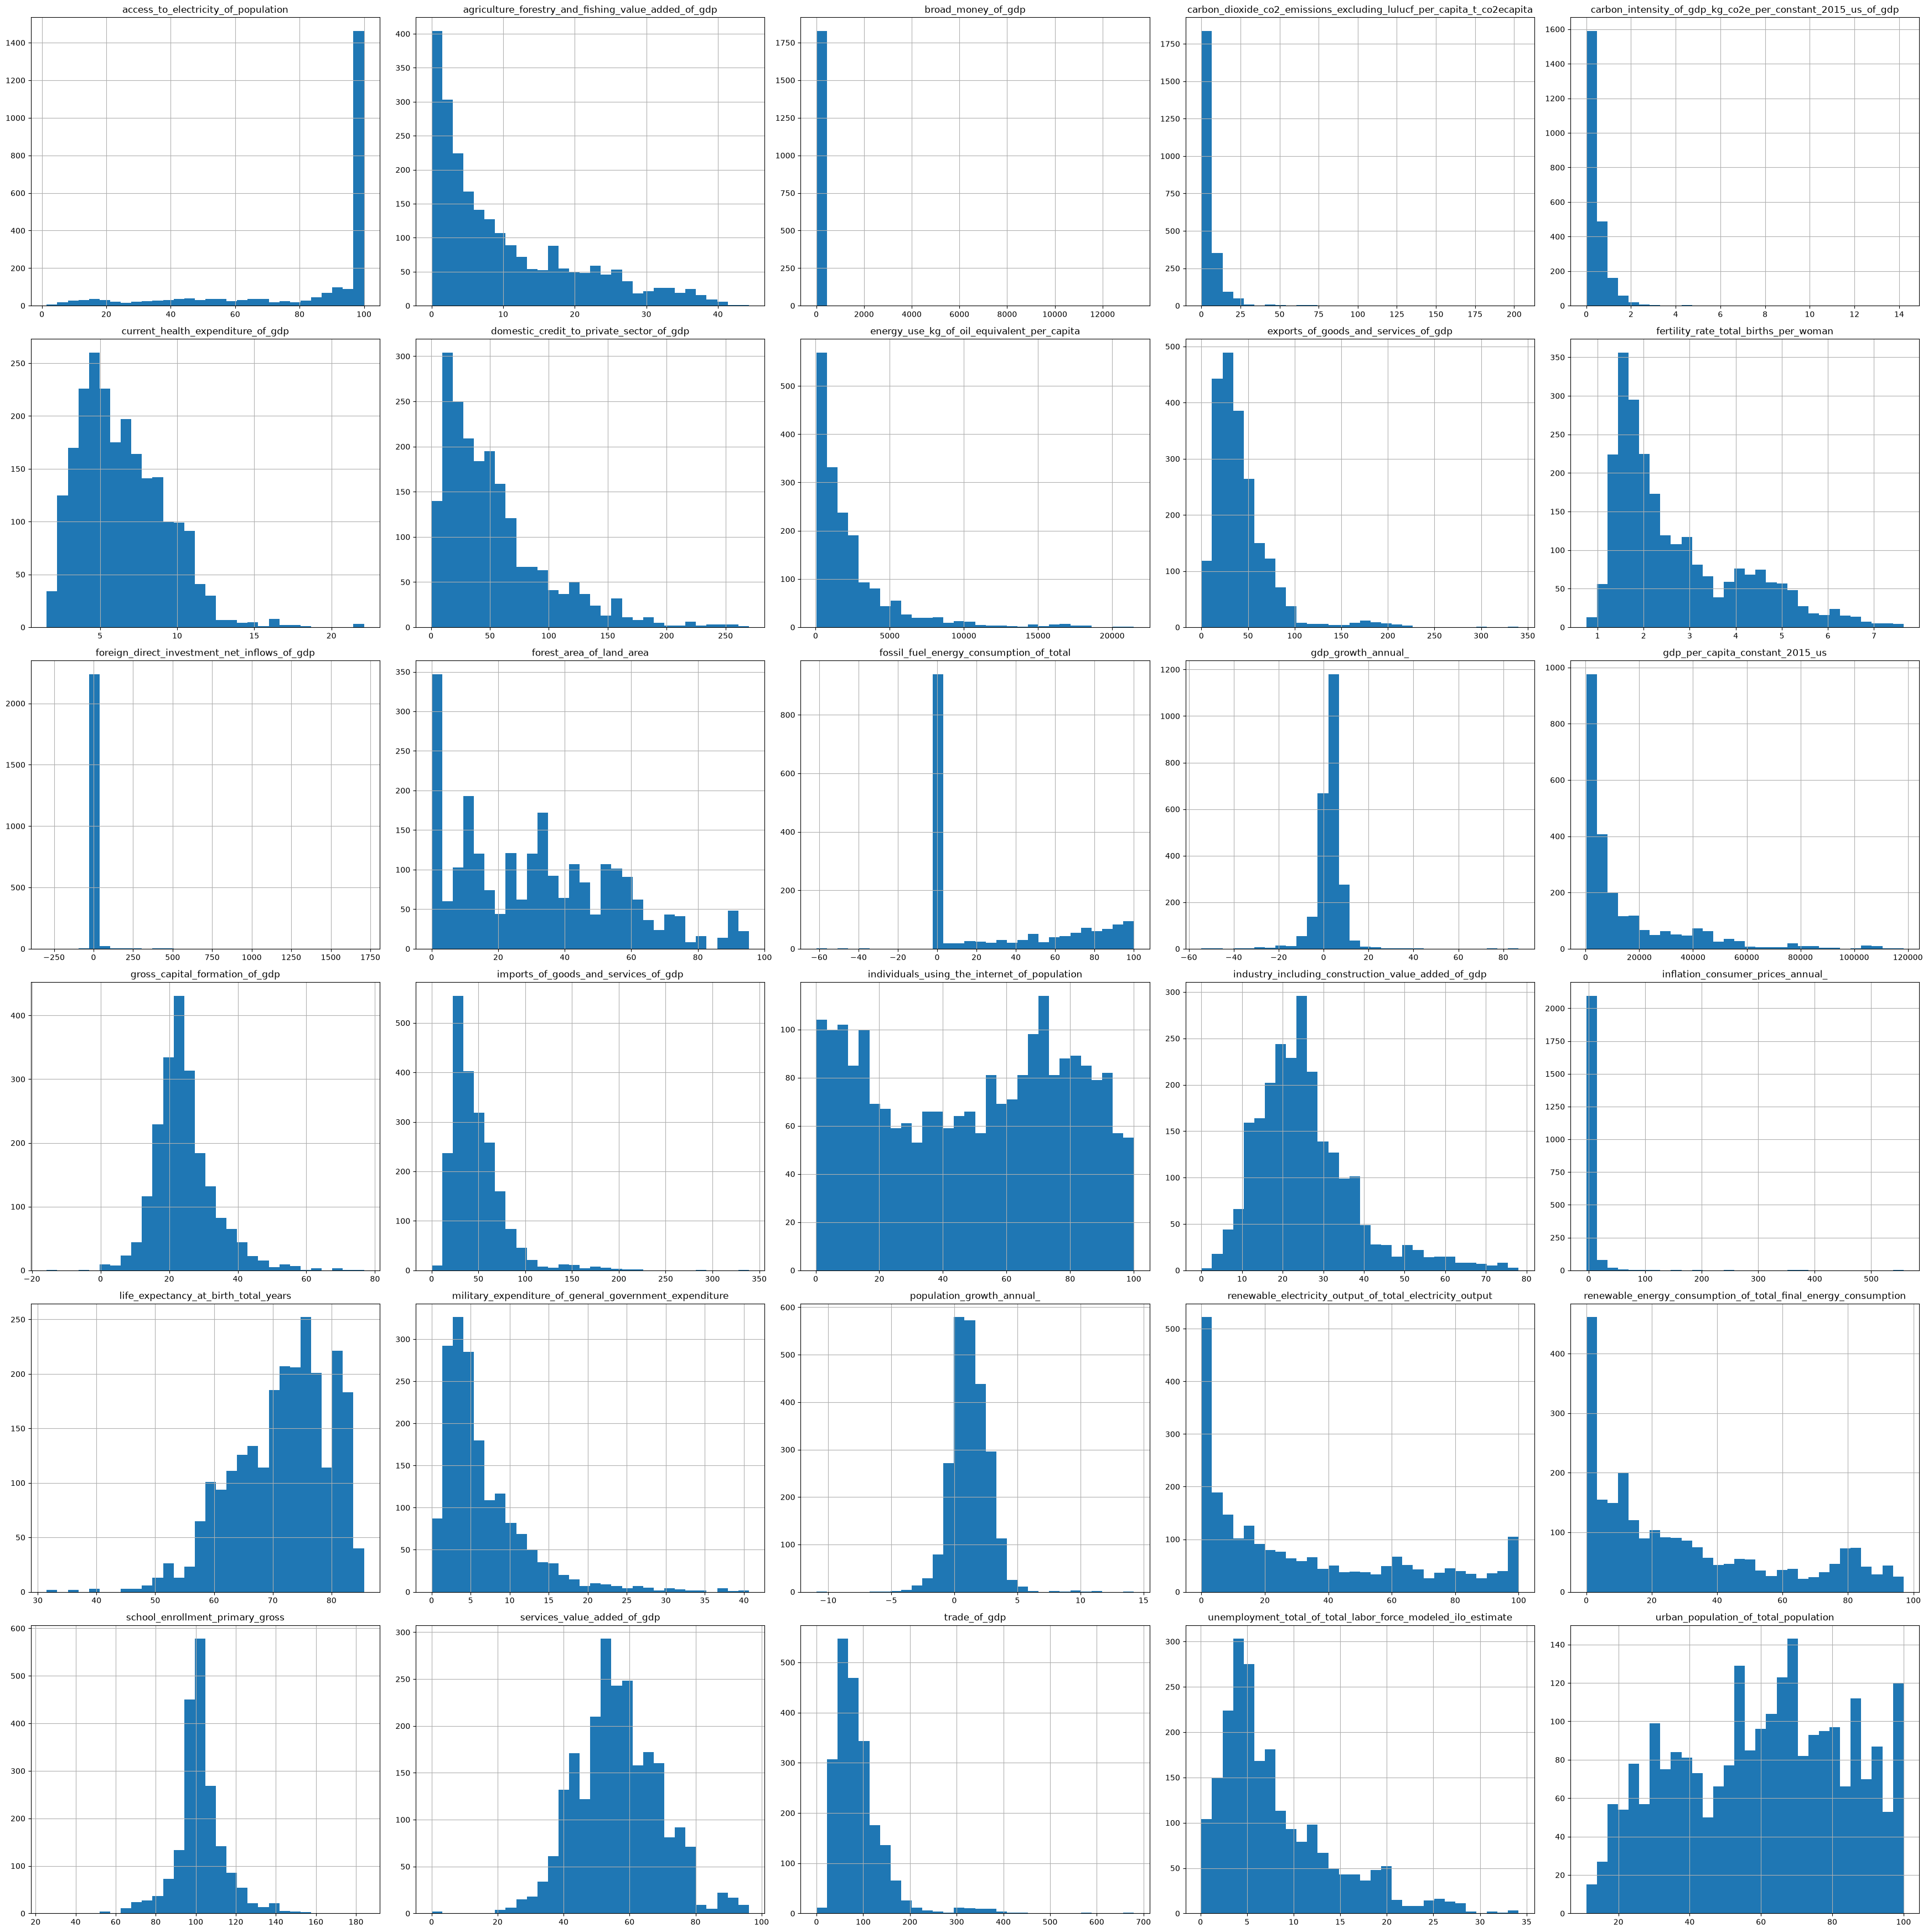

In [316]:
numeric_cols = df_countries.select_dtypes(include="number").columns.drop("year")

df_countries[numeric_cols].hist(
    figsize=(35, 35),
    bins=30
)

plt.tight_layout()
plt.show()

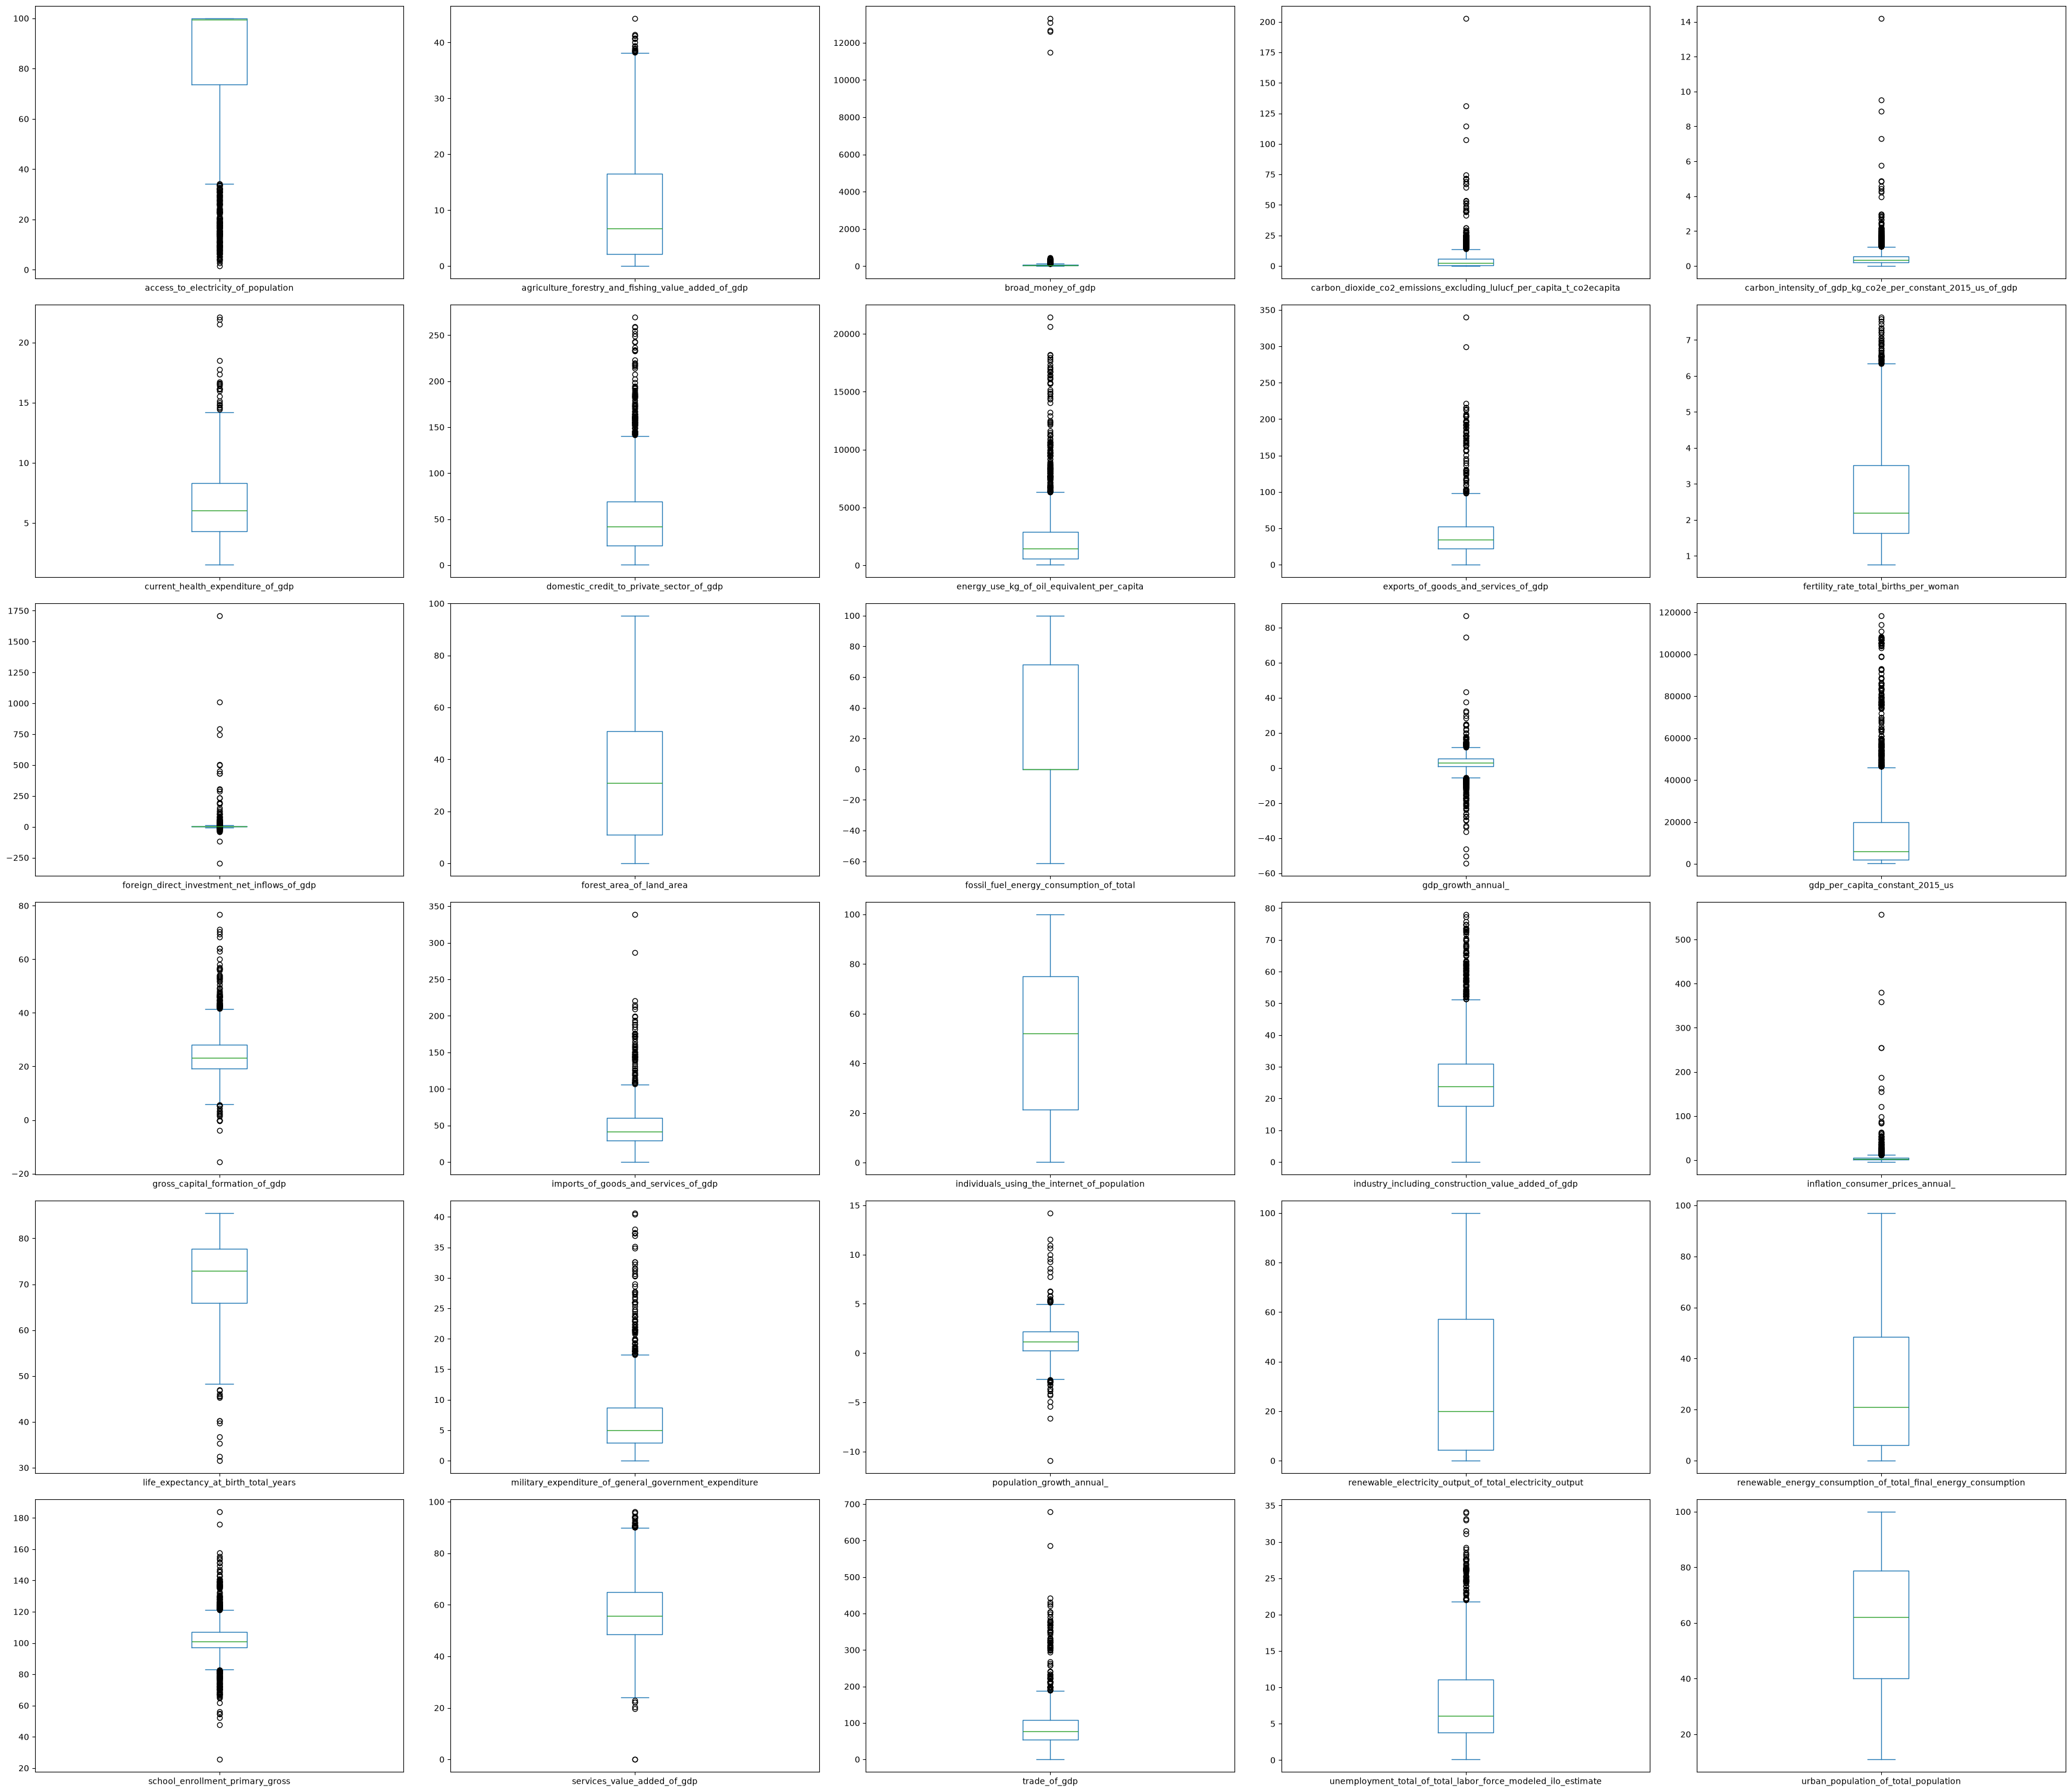

In [317]:
numeric_cols = df_countries.select_dtypes(include="number").columns.drop("year")

df_countries[numeric_cols].plot(
    kind="box",
    subplots=True,
    layout=(7, 5),
    figsize=(35, 35),
    sharex=False,
    sharey=False
)

plt.tight_layout()
plt.show()

In [318]:
df_countries.columns.tolist()

['country_name',
 'country_code',
 'year',
 'access_to_electricity_of_population',
 'agriculture_forestry_and_fishing_value_added_of_gdp',
 'broad_money_of_gdp',
 'carbon_dioxide_co2_emissions_excluding_lulucf_per_capita_t_co2ecapita',
 'carbon_intensity_of_gdp_kg_co2e_per_constant_2015_us_of_gdp',
 'current_health_expenditure_of_gdp',
 'domestic_credit_to_private_sector_of_gdp',
 'energy_use_kg_of_oil_equivalent_per_capita',
 'exports_of_goods_and_services_of_gdp',
 'fertility_rate_total_births_per_woman',
 'foreign_direct_investment_net_inflows_of_gdp',
 'forest_area_of_land_area',
 'fossil_fuel_energy_consumption_of_total',
 'gdp_growth_annual_',
 'gdp_per_capita_constant_2015_us',
 'gross_capital_formation_of_gdp',
 'imports_of_goods_and_services_of_gdp',
 'individuals_using_the_internet_of_population',
 'industry_including_construction_value_added_of_gdp',
 'inflation_consumer_prices_annual_',
 'life_expectancy_at_birth_total_years',
 'military_expenditure_of_general_government_ex

In [319]:
nan_summary = (
    pd.DataFrame({
        "nan_count": df_countries.isna().sum(),
        "nan_percentage": df_countries.isna().mean()
    })
    .reset_index(names="Series Name")
    .sort_values("nan_percentage", ascending=False)
)

nan_summary.head()

,Series Name,nan_count,nan_percentage
15,fossil_fuel_energy_consumption_of_total,731,0.298611
10,energy_use_kg_of_oil_equivalent_per_capita,686,0.280229
24,military_expenditure_of_general_government_exp...,678,0.276961
5,broad_money_of_gdp,615,0.251225
28,school_enrollment_primary_gross,490,0.200163


In [320]:
negative_counts = df_countries.select_dtypes(include="number").apply(
    lambda col: (col < 0).sum())


negative_counts.sort_values(ascending=False).head(10)

Series Name
gdp_growth_annual_                                                       453
population_growth_annual_                                                415
inflation_consumer_prices_annual_                                        206
foreign_direct_investment_net_inflows_of_gdp                             179
fossil_fuel_energy_consumption_of_total                                    6
gross_capital_formation_of_gdp                                             3
broad_money_of_gdp                                                         0
current_health_expenditure_of_gdp                                          0
carbon_intensity_of_gdp_kg_co2e_per_constant_2015_us_of_gdp                0
carbon_dioxide_co2_emissions_excluding_lulucf_per_capita_t_co2ecapita      0
dtype: int64

In [321]:
df_countries.loc[
    df_countries["fossil_fuel_energy_consumption_of_total"] < 0,
    "fossil_fuel_energy_consumption_of_total"
] = np.nan

df_countries.loc[
    df_countries["gross_capital_formation_of_gdp"] < 0,
    "gross_capital_formation_of_gdp"
] = np.nan

In [322]:
df_countries.columns.tolist()

['country_name',
 'country_code',
 'year',
 'access_to_electricity_of_population',
 'agriculture_forestry_and_fishing_value_added_of_gdp',
 'broad_money_of_gdp',
 'carbon_dioxide_co2_emissions_excluding_lulucf_per_capita_t_co2ecapita',
 'carbon_intensity_of_gdp_kg_co2e_per_constant_2015_us_of_gdp',
 'current_health_expenditure_of_gdp',
 'domestic_credit_to_private_sector_of_gdp',
 'energy_use_kg_of_oil_equivalent_per_capita',
 'exports_of_goods_and_services_of_gdp',
 'fertility_rate_total_births_per_woman',
 'foreign_direct_investment_net_inflows_of_gdp',
 'forest_area_of_land_area',
 'fossil_fuel_energy_consumption_of_total',
 'gdp_growth_annual_',
 'gdp_per_capita_constant_2015_us',
 'gross_capital_formation_of_gdp',
 'imports_of_goods_and_services_of_gdp',
 'individuals_using_the_internet_of_population',
 'industry_including_construction_value_added_of_gdp',
 'inflation_consumer_prices_annual_',
 'life_expectancy_at_birth_total_years',
 'military_expenditure_of_general_government_ex

In [323]:
df_countries["trade_openness_ratio"] = (
    df_countries["exports_of_goods_and_services_of_gdp"]
    + df_countries["imports_of_goods_and_services_of_gdp"]
)

comparison = df_countries[
    ["trade_of_gdp", "trade_openness_ratio"]
].copy()

comparison["difference"] = (
    comparison["trade_of_gdp"]
    - comparison["trade_openness_ratio"]
)

comparison.describe()

Series Name,trade_of_gdp,trade_openness_ratio,difference
count,2154.000000,2154.000000,2.154000e+03
mean,90.515844,90.515844,-8.988992e-17
std,58.460714,58.460714,1.143992e-14
min,0.000000,0.000000,-5.684342e-14
25%,54.604223,54.604223,0.000000e+00
50%,77.571275,77.571275,0.000000e+00
75%,107.821133,107.821133,0.000000e+00
max,679.232773,679.232773,1.136868e-13


In [324]:
# as trade_of_gdp == trade_openness_ratio delete the two columns
df_countries = df_countries.drop(columns=['exports_of_goods_and_services_of_gdp', 'imports_of_goods_and_services_of_gdp'])

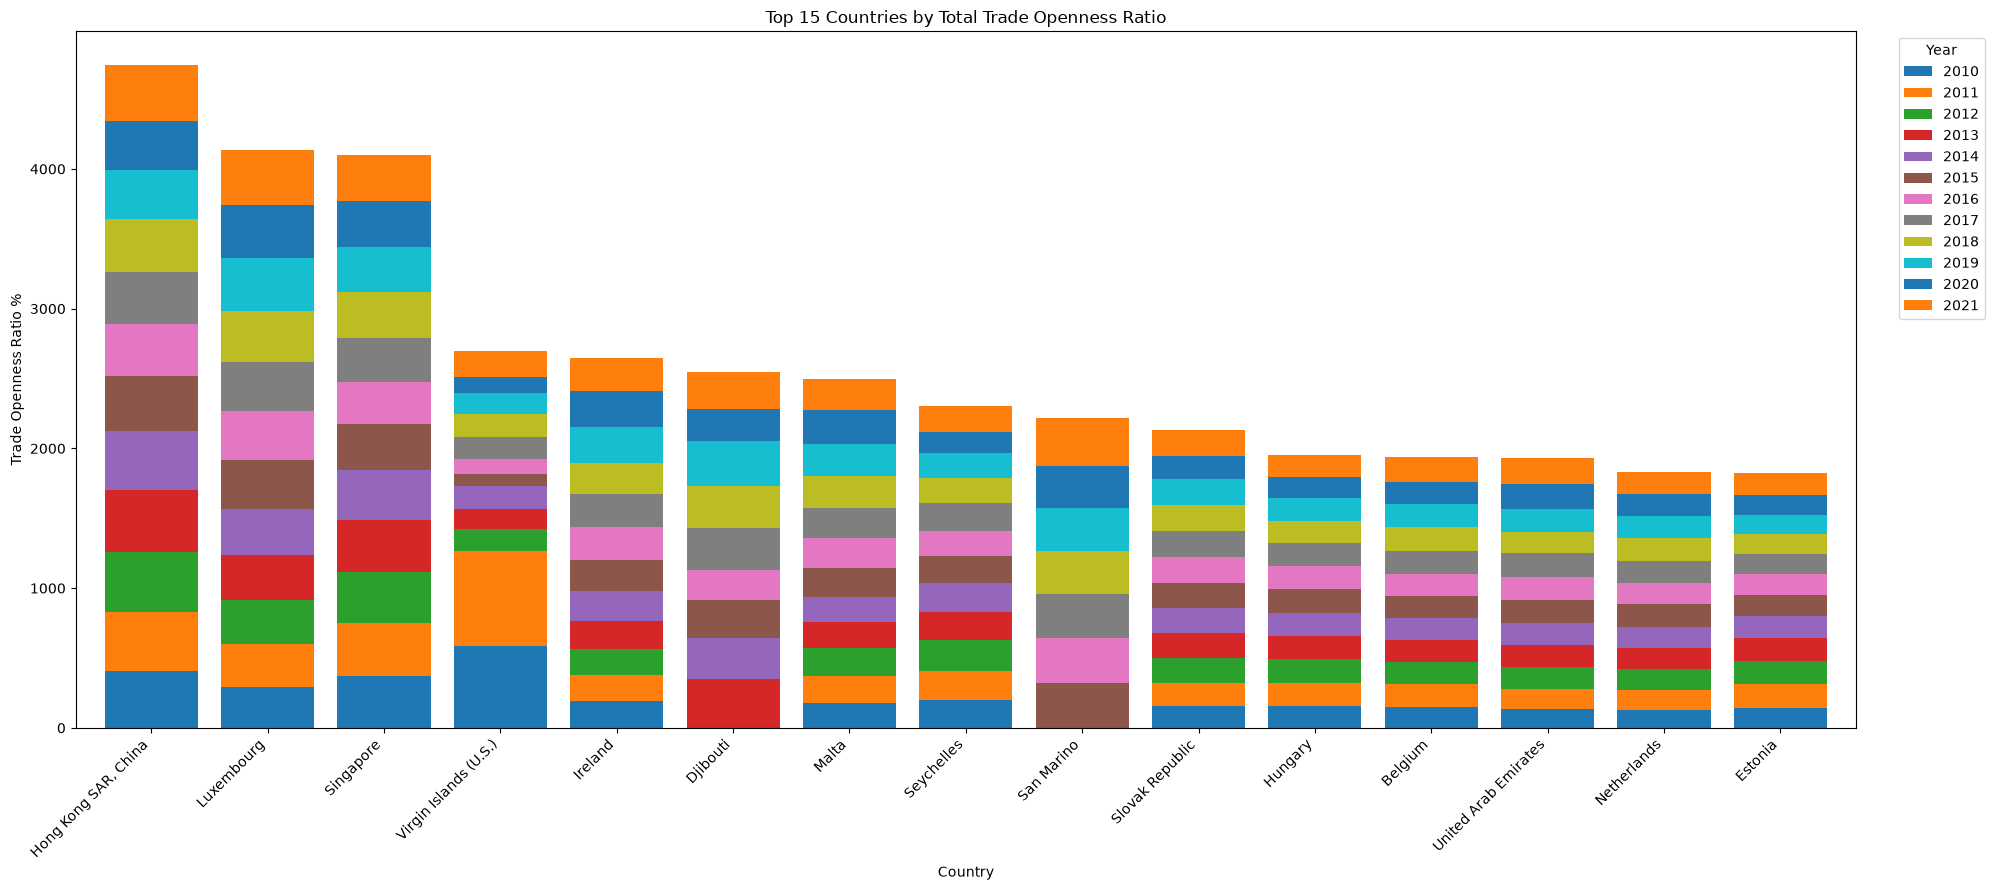

In [325]:
# Get total for ranking
country_totals = (
    df_countries
    .groupby("country_name")["trade_openness_ratio"]
    .sum()
    .sort_values(ascending=False)
)

# Top 15 countries
top_15_countries = country_totals.head(15).index

# Keep only top 15
top_15_df = df_countries[
    df_countries["country_name"].isin(top_15_countries)
].copy()

# Put years into columns
plot_data = top_15_df.pivot(
    index="country_name",
    columns="year",
    values="trade_openness_ratio"
)

# Order countries by their total
plot_data = plot_data.loc[top_15_countries]

# Stacked bar plot
ax = plot_data.plot(
    kind="bar",
    stacked=True,
    figsize=(20, 9),
    width=0.8
)

plt.title("Top 15 Countries by Total Trade Openness Ratio")
plt.xlabel("Country")
plt.ylabel("Trade Openness Ratio %")

plt.xticks(rotation=45, ha="right")
plt.legend(
    title="Year",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

C:\Users\minam\AppData\Local\Temp\ipykernel_10500\1383808293.py:24: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(
C:\Users\minam\AppData\Local\Temp\ipykernel_10500\1383808293.py:45: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(


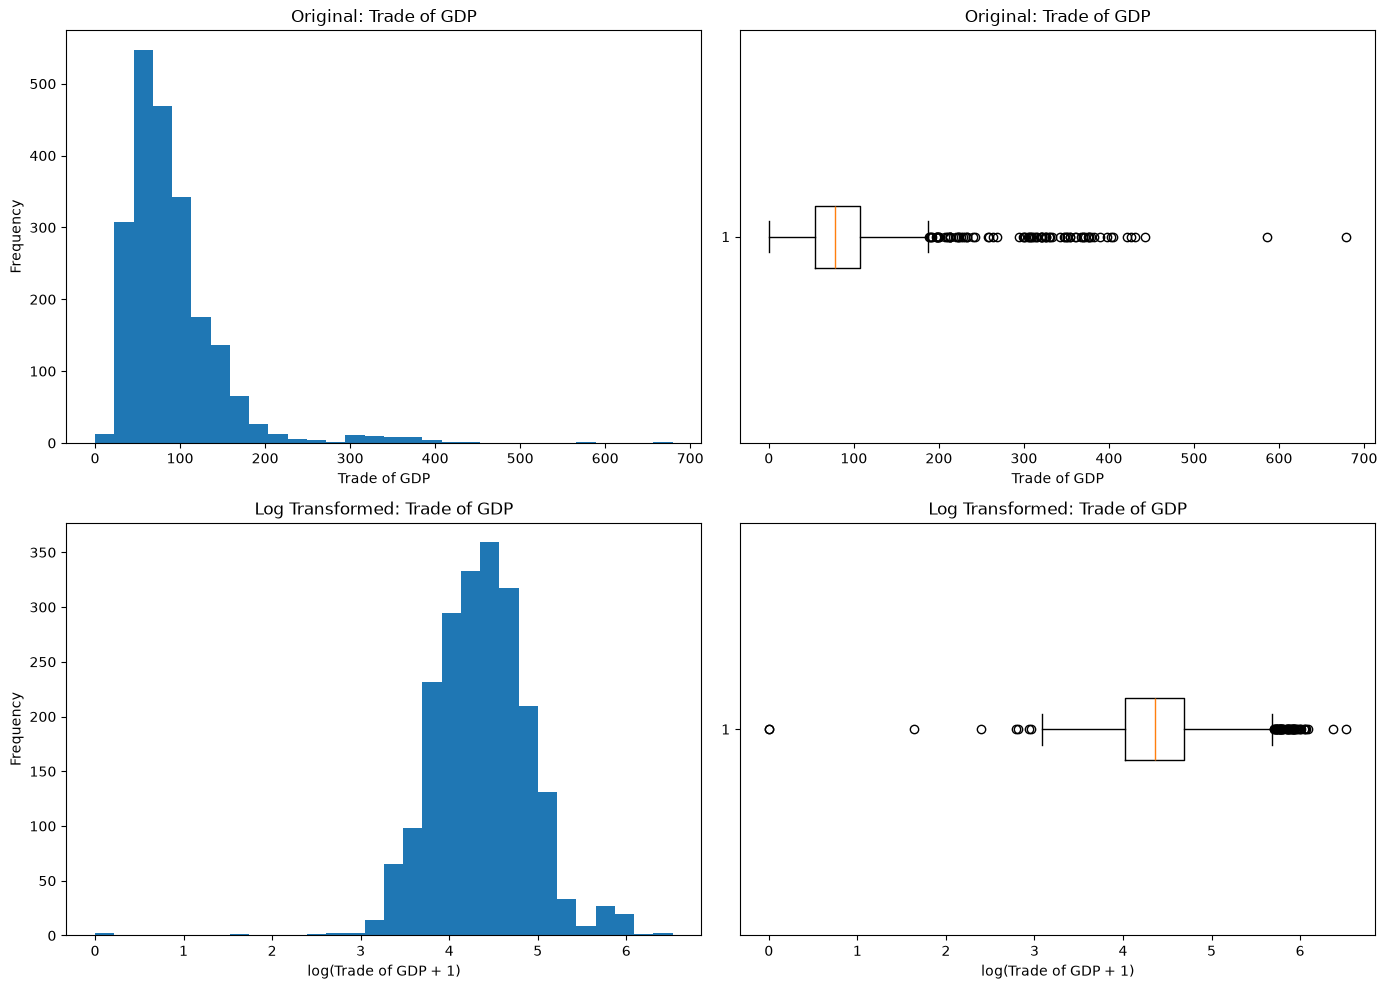

In [326]:
import numpy as np
import matplotlib.pyplot as plt

# Log transformation
df_countries['trade_of_gdp_log'] = np.log1p(df_countries['trade_of_gdp'])

# Create 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -------------------------
# Original: Histogram
# -------------------------
axes[0, 0].hist(
    df_countries['trade_of_gdp'].dropna(),
    bins=30
)
axes[0, 0].set_title('Original: Trade of GDP')
axes[0, 0].set_xlabel('Trade of GDP')
axes[0, 0].set_ylabel('Frequency')

# -------------------------
# Original: Boxplot
# -------------------------
axes[0, 1].boxplot(
    df_countries['trade_of_gdp'].dropna(),
    vert=False
)
axes[0, 1].set_title('Original: Trade of GDP')
axes[0, 1].set_xlabel('Trade of GDP')

# -------------------------
# Log: Histogram
# -------------------------
axes[1, 0].hist(
    df_countries['trade_of_gdp_log'].dropna(),
    bins=30
)
axes[1, 0].set_title('Log Transformed: Trade of GDP')
axes[1, 0].set_xlabel('log(Trade of GDP + 1)')
axes[1, 0].set_ylabel('Frequency')

# -------------------------
# Log: Boxplot
# -------------------------
axes[1, 1].boxplot(
    df_countries['trade_of_gdp_log'].dropna(),
    vert=False
)
axes[1, 1].set_title('Log Transformed: Trade of GDP')
axes[1, 1].set_xlabel('log(Trade of GDP + 1)')

plt.tight_layout()
plt.show()

In [327]:
df_countries.drop(columns=['trade_of_gdp', 'trade_openness_ratio'], inplace=True)

In [328]:
df_countries['Socioeconomic_developmen_Index'] = (df_countries["access_to_electricity_of_population"] + df_countries["individuals_using_the_internet_of_population"] + df_countries["life_expectancy_at_birth_total_years"] + df_countries["urban_population_of_total_population"]) / 4

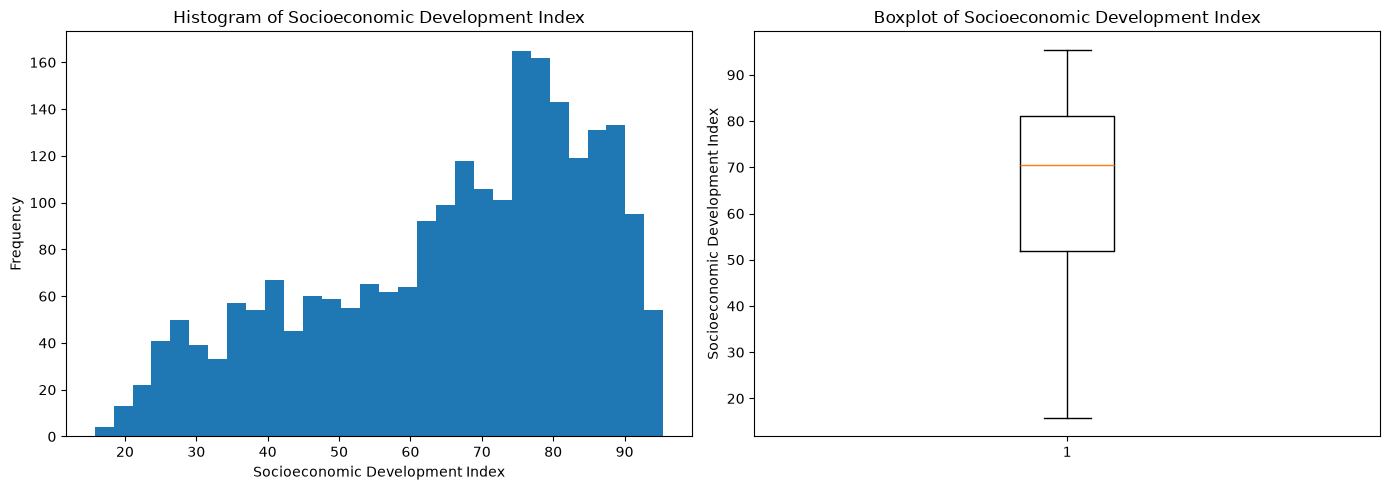

In [329]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(
    df_countries["Socioeconomic_developmen_Index"].dropna(),
    bins=30
)
axes[0].set_xlabel("Socioeconomic Development Index")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Histogram of Socioeconomic Development Index")

# Boxplot
axes[1].boxplot(
    df_countries["Socioeconomic_developmen_Index"].dropna()
)
axes[1].set_ylabel("Socioeconomic Development Index")
axes[1].set_title("Boxplot of Socioeconomic Development Index")

plt.tight_layout()
plt.show()

In [330]:
df_countries.drop(columns=[
    "access_to_electricity_of_population",
    "individuals_using_the_internet_of_population",
    "life_expectancy_at_birth_total_years",
    "urban_population_of_total_population"
], inplace=True)

In [331]:
from sklearn.preprocessing import StandardScaler

energy_cols = [
    "energy_use_kg_of_oil_equivalent_per_capita",
    "carbon_dioxide_co2_emissions_excluding_lulucf_per_capita_t_co2ecapita"
]

# 1. Apply log transformation directly on raw, positive data
#    (Using log1p handles 0 values safely)
df_log = np.log1p(df_countries[energy_cols])

# 2. Standardize the log-transformed variables
scaler = StandardScaler()
scaled_array = scaler.fit_transform(df_log)
df_scaled = pd.DataFrame(scaled_array, columns=energy_cols, index=df_countries.index)

# 3. Create composite index handling missing values row-wise
df_countries["Energy_Environmental_Index"] = df_scaled.mean(axis=1, skipna=True)

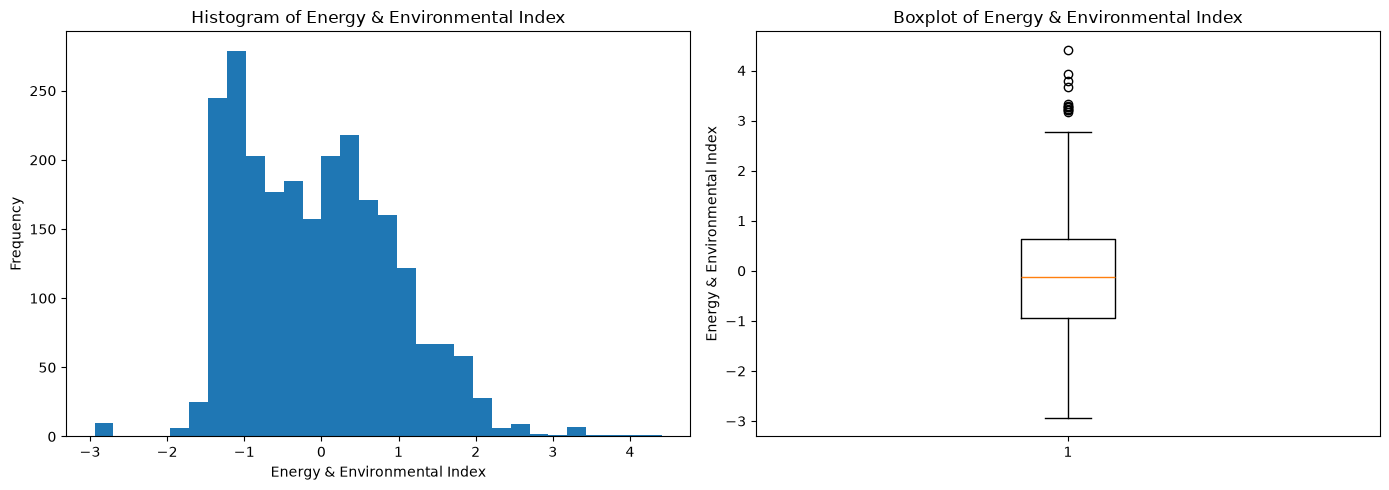

In [332]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Remove NaN values
index_data = df_countries["Energy_Environmental_Index"].dropna()

# Histogram
axes[0].hist(index_data, bins=30)
axes[0].set_xlabel("Energy & Environmental Index")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Histogram of Energy & Environmental Index")

# Boxplot
axes[1].boxplot(index_data)
axes[1].set_ylabel("Energy & Environmental Index")
axes[1].set_title("Boxplot of Energy & Environmental Index")

plt.tight_layout()
plt.show()

In [333]:
df_countries.drop(columns=energy_cols, inplace=True)

In [334]:
df_countries.columns.tolist()

['country_name',
 'country_code',
 'year',
 'agriculture_forestry_and_fishing_value_added_of_gdp',
 'broad_money_of_gdp',
 'carbon_intensity_of_gdp_kg_co2e_per_constant_2015_us_of_gdp',
 'current_health_expenditure_of_gdp',
 'domestic_credit_to_private_sector_of_gdp',
 'fertility_rate_total_births_per_woman',
 'foreign_direct_investment_net_inflows_of_gdp',
 'forest_area_of_land_area',
 'fossil_fuel_energy_consumption_of_total',
 'gdp_growth_annual_',
 'gdp_per_capita_constant_2015_us',
 'gross_capital_formation_of_gdp',
 'industry_including_construction_value_added_of_gdp',
 'inflation_consumer_prices_annual_',
 'military_expenditure_of_general_government_expenditure',
 'population_growth_annual_',
 'renewable_electricity_output_of_total_electricity_output',
 'renewable_energy_consumption_of_total_final_energy_consumption',
 'school_enrollment_primary_gross',
 'services_value_added_of_gdp',
 'unemployment_total_of_total_labor_force_modeled_ilo_estimate',
 'trade_of_gdp_log',
 'Socioec

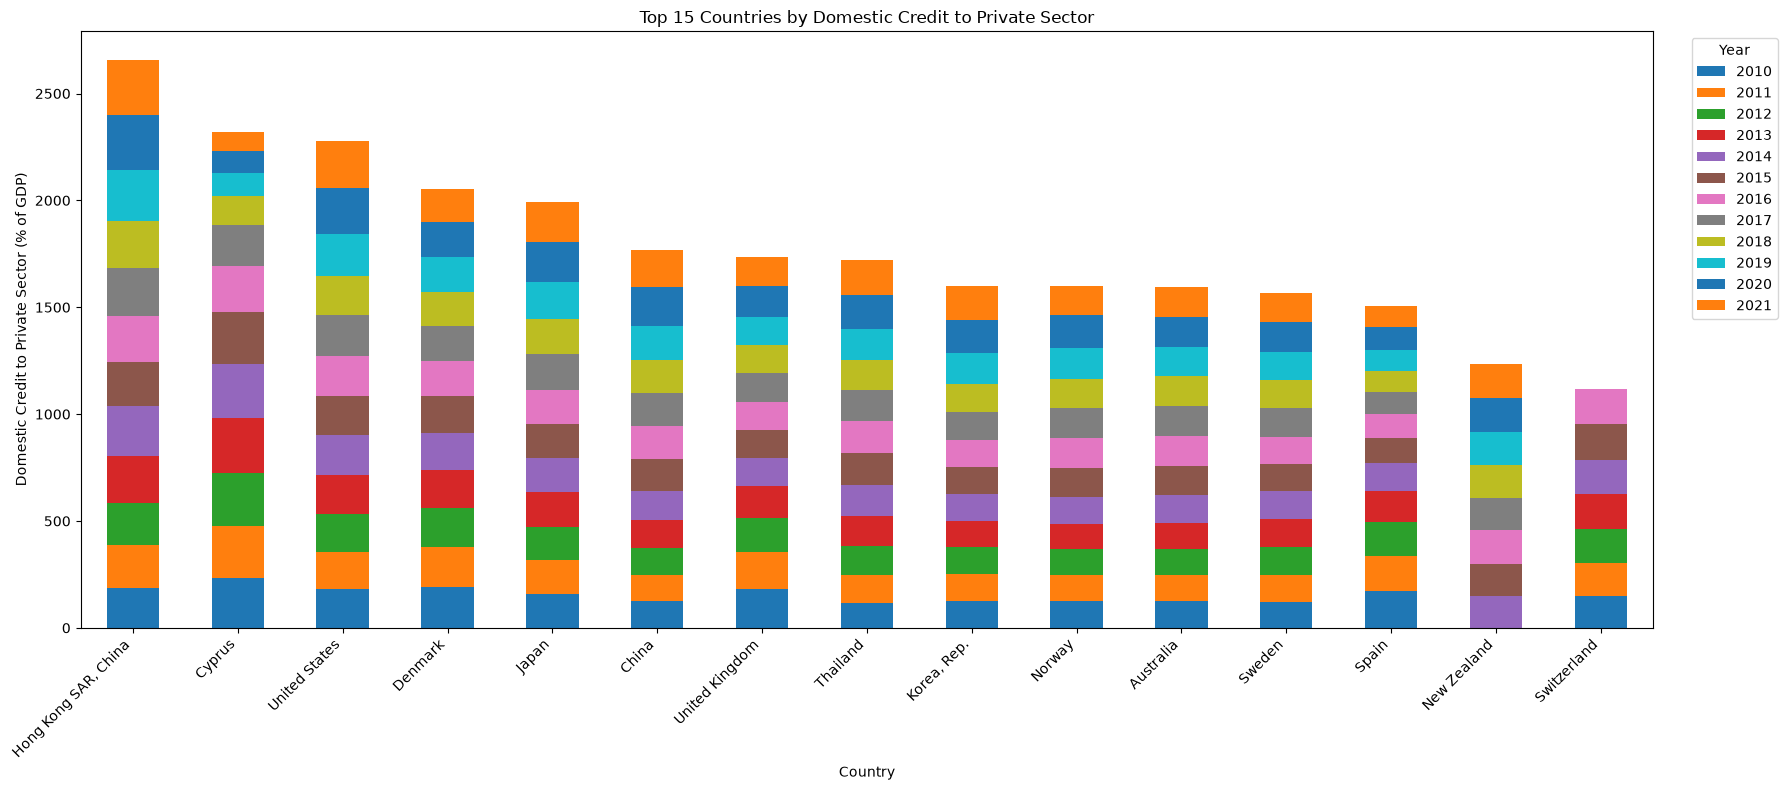

In [ ]:
feature = "domestic_credit_to_private_sector_of_gdp"

# 1. Find the top 15 countries based on their average value
top_15_countries = (
    df_countries
    .groupby("country_name")[feature]
    .mean()
    .nlargest(15)
    .index
)

# 2. Keep only those countries
top_15 = df_countries[
    df_countries["country_name"].isin(top_15_countries)
]

# 3. Put years as columns
plot_data = top_15.pivot_table(
    index="country_name",
    columns="year",
    values=feature,
    aggfunc="mean"
)

# 4. Sort countries by their overall sum
plot_data = plot_data.loc[
    plot_data.sum(axis=1).sort_values(ascending=False).index
]

# 5. Plot
ax = plot_data.plot(
    kind="bar",
    stacked=True,
    figsize=(18, 8)
)

plt.xlabel("Country")
plt.ylabel("Domestic Credit to Private Sector (% of GDP)")
plt.title("Top 15 Countries by Domestic Credit to Private Sector")

plt.xticks(rotation=45, ha="right")
plt.legend(title="Year", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [336]:
df_countries['domestic_credit_to_private_sector_of_gdp_log'] = np.log1p(df_countries['domestic_credit_to_private_sector_of_gdp'])

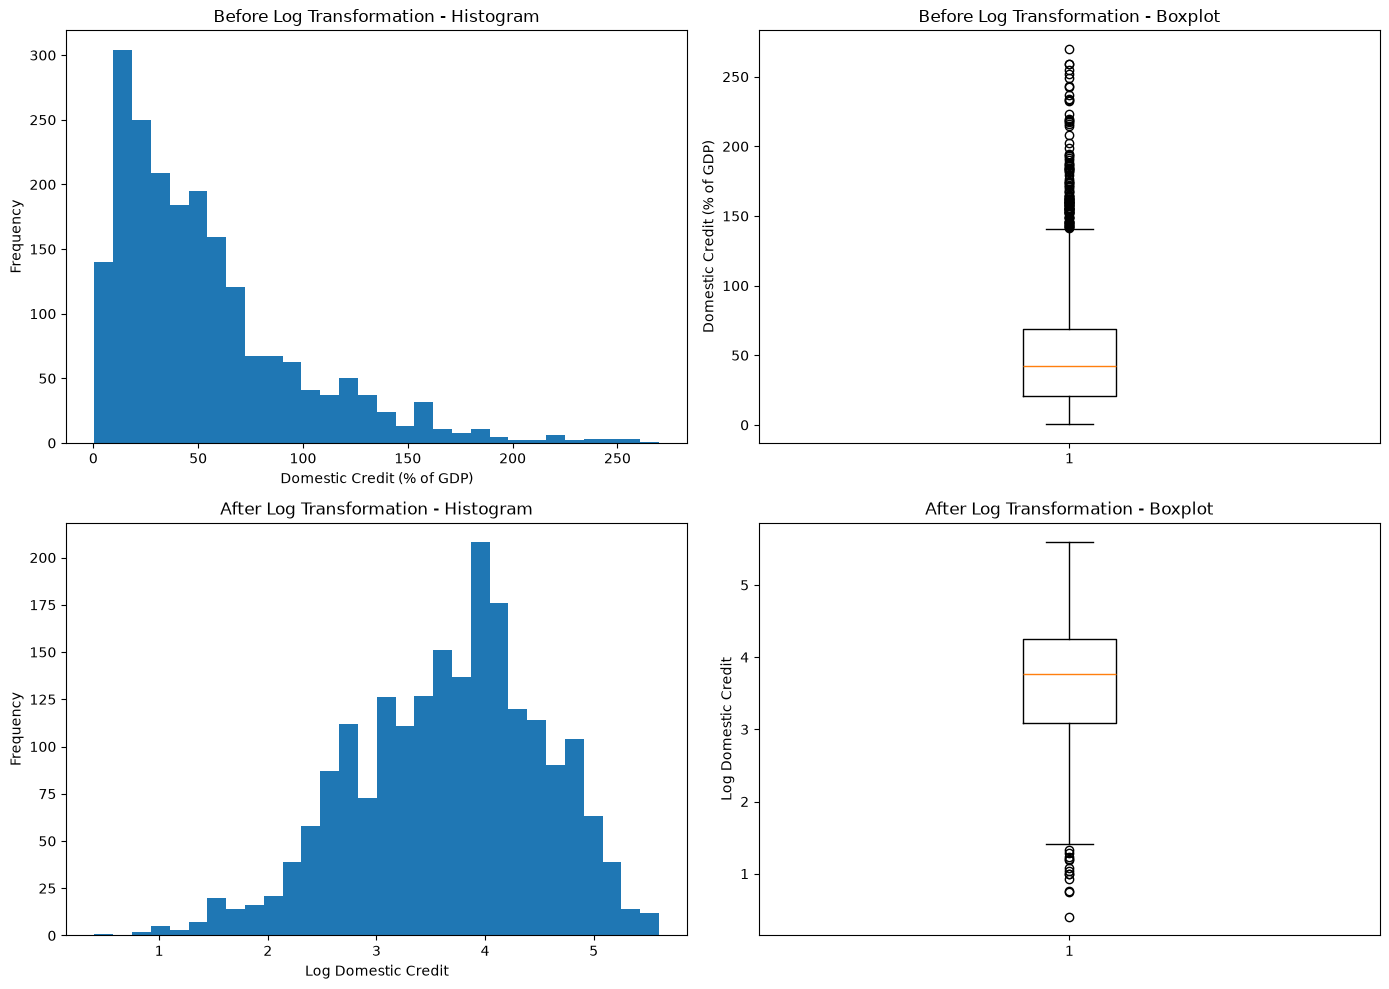

In [337]:
original = df_countries["domestic_credit_to_private_sector_of_gdp"].dropna()
logged = df_countries["domestic_credit_to_private_sector_of_gdp_log"].dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---------------- BEFORE ----------------

# Histogram
axes[0, 0].hist(original, bins=30)
axes[0, 0].set_title("Before Log Transformation - Histogram")
axes[0, 0].set_xlabel("Domestic Credit (% of GDP)")
axes[0, 0].set_ylabel("Frequency")

# Boxplot
axes[0, 1].boxplot(original)
axes[0, 1].set_title("Before Log Transformation - Boxplot")
axes[0, 1].set_ylabel("Domestic Credit (% of GDP)")


# ---------------- AFTER ----------------

# Histogram
axes[1, 0].hist(logged, bins=30)
axes[1, 0].set_title("After Log Transformation - Histogram")
axes[1, 0].set_xlabel("Log Domestic Credit")
axes[1, 0].set_ylabel("Frequency")

# Boxplot
axes[1, 1].boxplot(logged)
axes[1, 1].set_title("After Log Transformation - Boxplot")
axes[1, 1].set_ylabel("Log Domestic Credit")

plt.tight_layout()
plt.show()

In [338]:
df_countries.drop(columns= 'domestic_credit_to_private_sector_of_gdp', inplace=True)

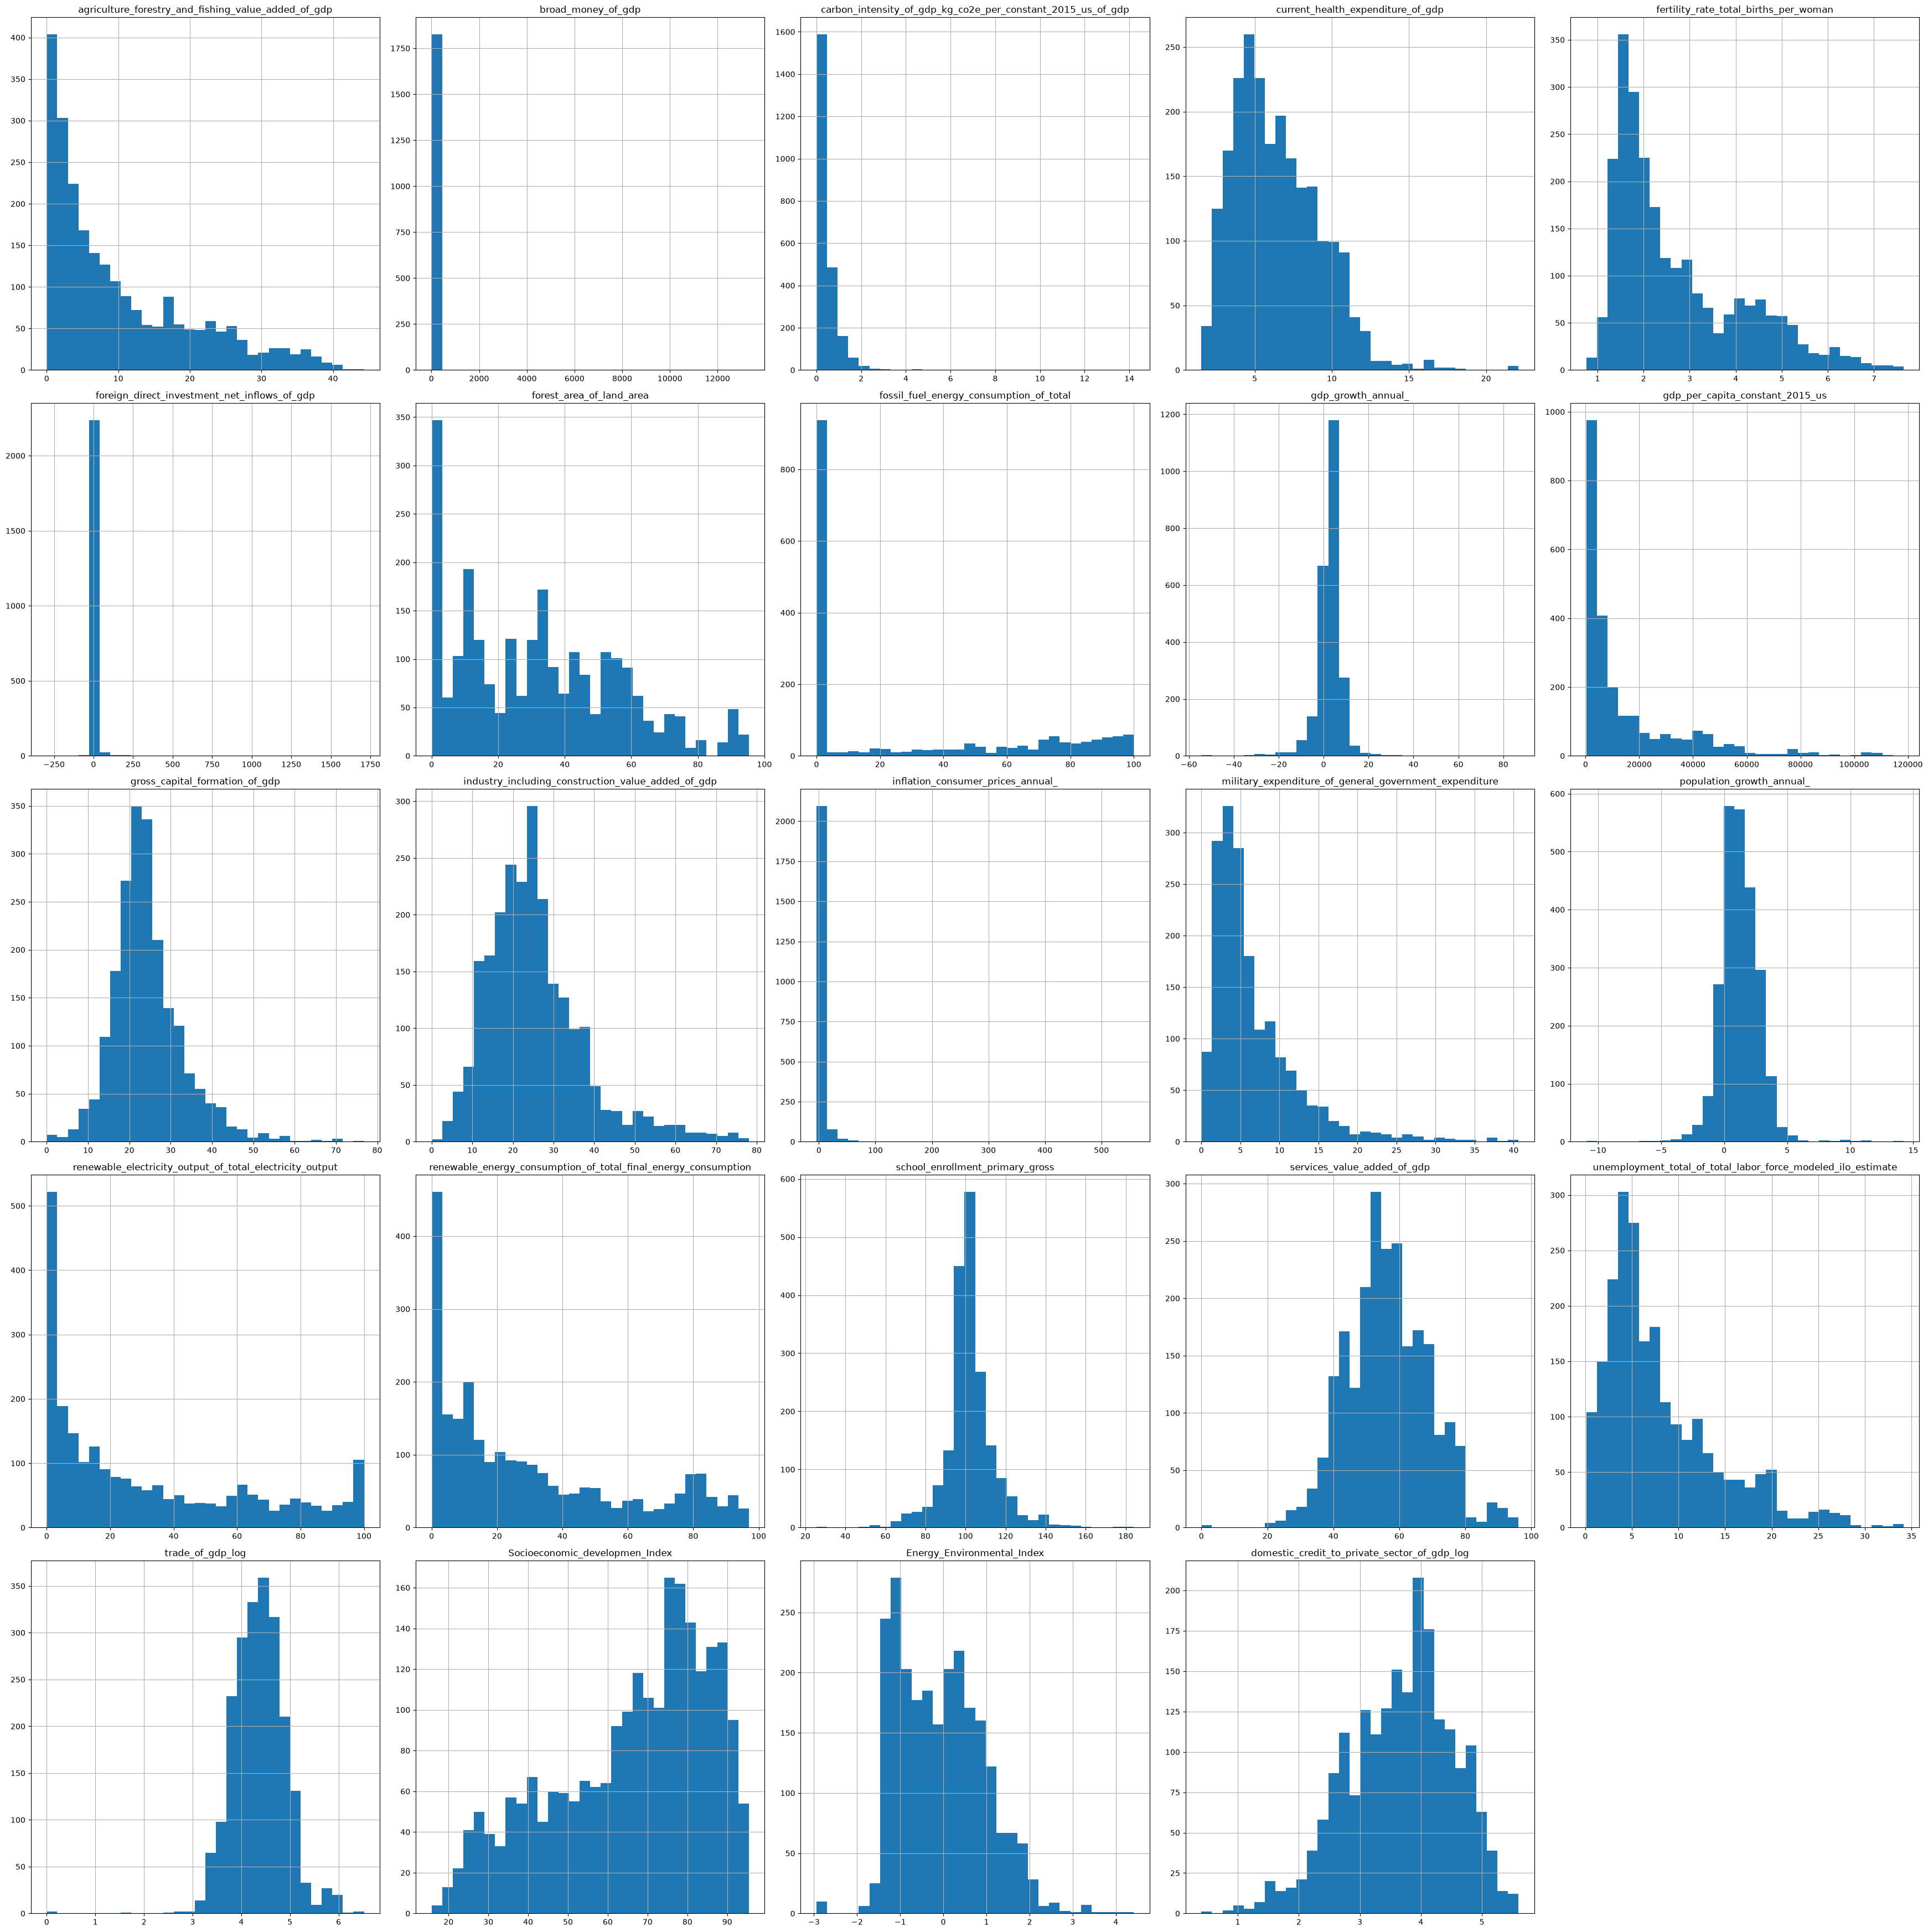

In [339]:
numeric_cols = df_countries.select_dtypes(include="number").columns.drop("year")

df_countries[numeric_cols].hist(
    figsize=(35, 35),
    bins=30
)

plt.tight_layout()
plt.show()

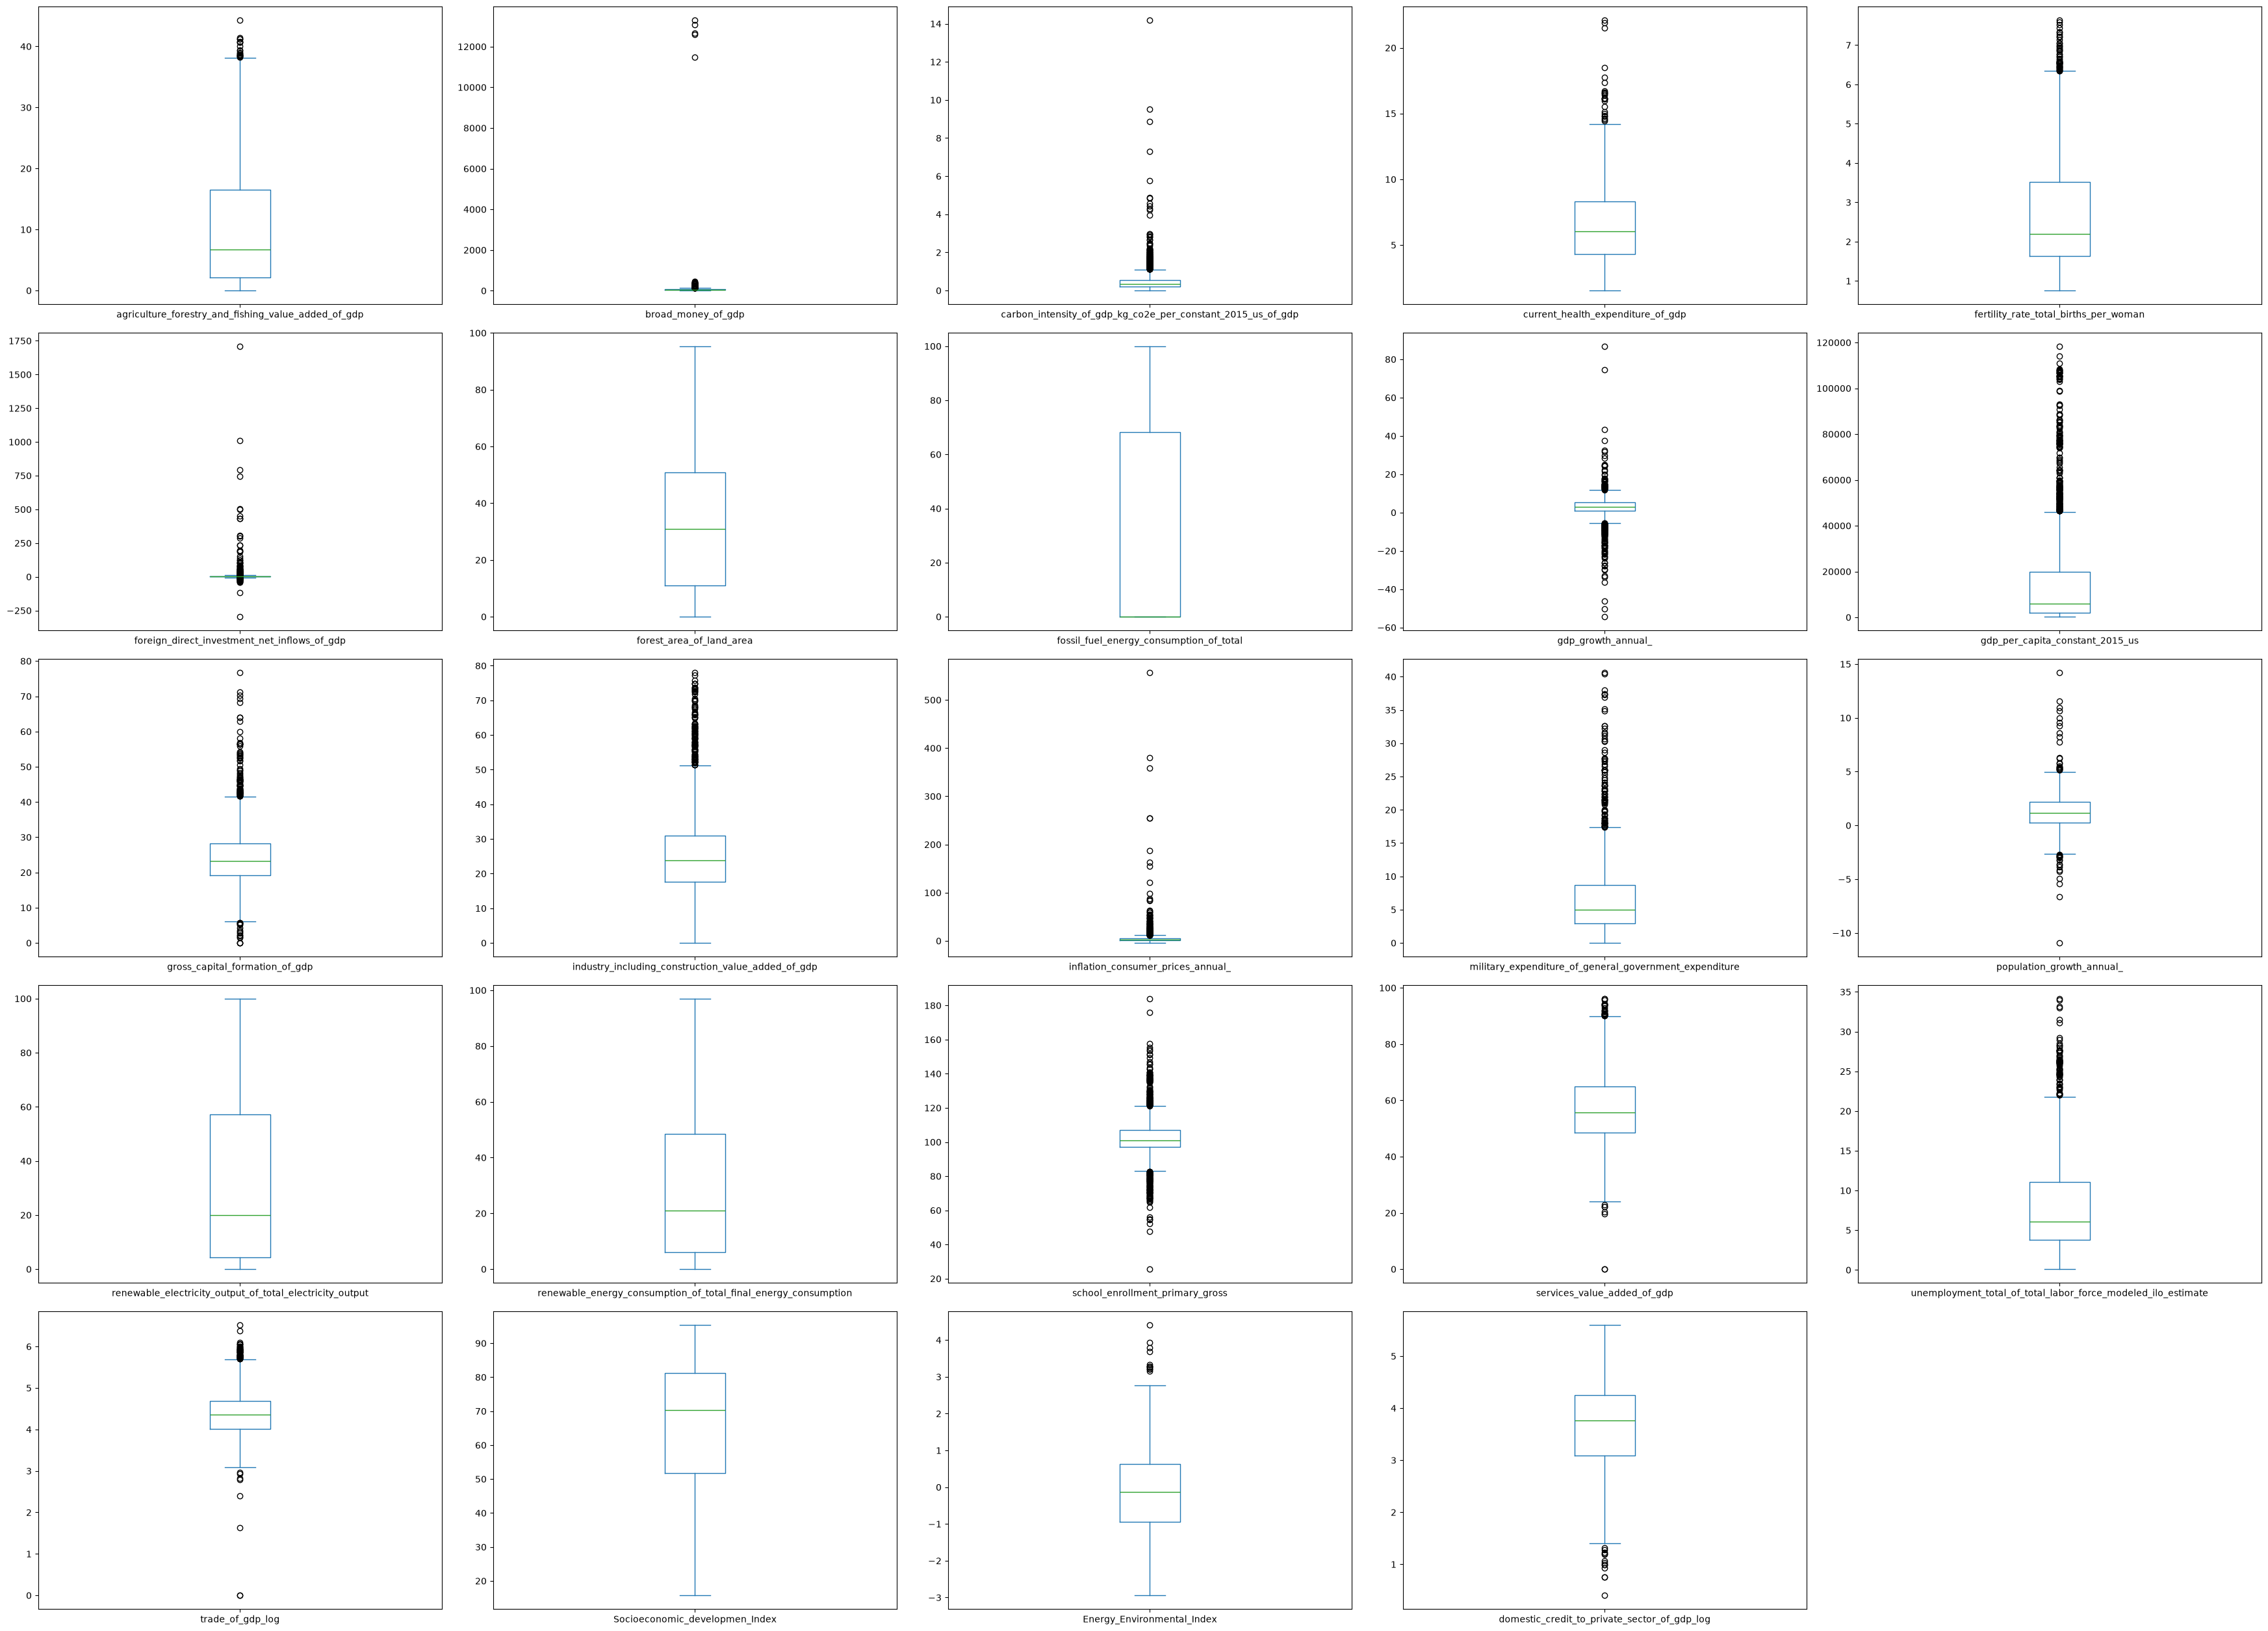

In [340]:
numeric_cols = df_countries.select_dtypes(include="number").columns.drop("year")

df_countries[numeric_cols].plot(
    kind="box",
    subplots=True,
    layout=(7, 5),
    figsize=(35, 35),
    sharex=False,
    sharey=False
)

plt.tight_layout()
plt.show()

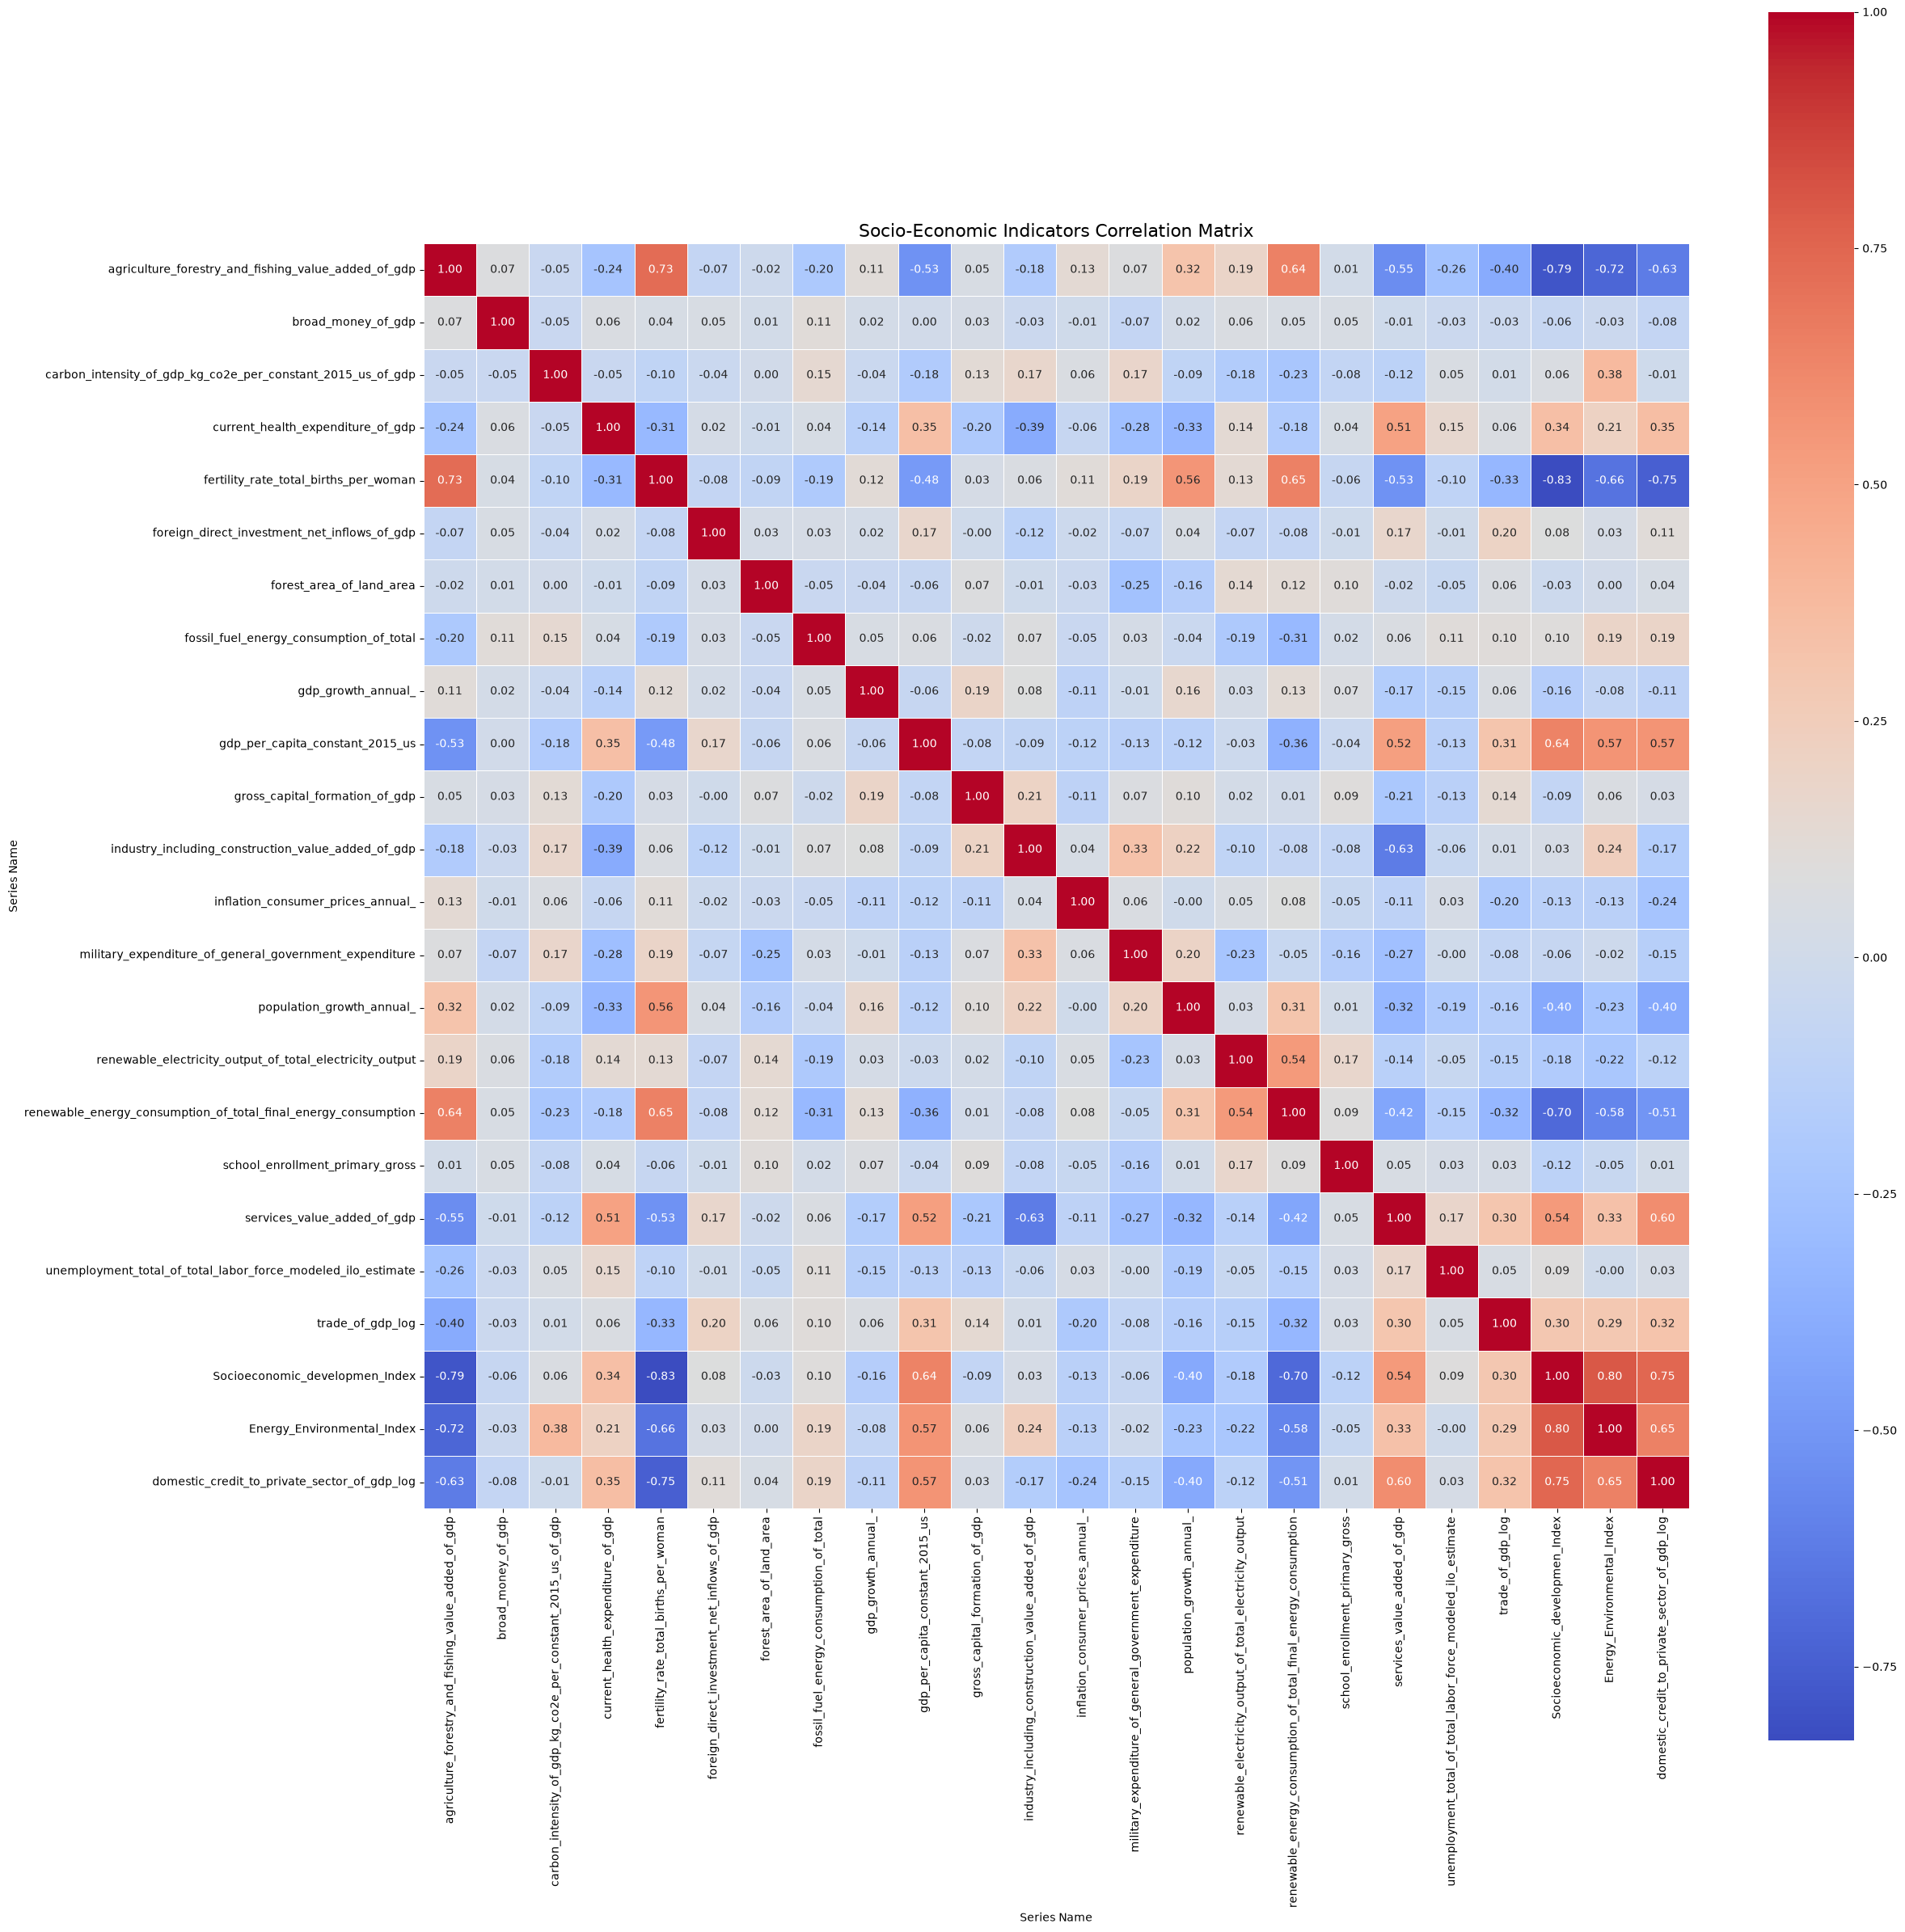

In [341]:
numeric_cols = df_countries.select_dtypes(include="number").columns.drop("year")

# 1. Compute the correlation matrix
corr_matrix = df_countries[numeric_cols].corr()

# 2. Plot the correlation matrix heatmap
plt.figure(figsize=(25, 25))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    square=True,
    linewidths=0.5
)

plt.title("Socio-Economic Indicators Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()

In [342]:
df_describe2 = df_countries.iloc[:, 3:].describe()
df_describe2

Series Name,agriculture_forestry_and_fishing_value_added_of_gdp,broad_money_of_gdp,carbon_intensity_of_gdp_kg_co2e_per_constant_2015_us_of_gdp,current_health_expenditure_of_gdp,fertility_rate_total_births_per_woman,foreign_direct_investment_net_inflows_of_gdp,forest_area_of_land_area,fossil_fuel_energy_consumption_of_total,gdp_growth_annual_,gdp_per_capita_constant_2015_us,...,population_growth_annual_,renewable_electricity_output_of_total_electricity_output,renewable_energy_consumption_of_total_final_energy_consumption,school_enrollment_primary_gross,services_value_added_of_gdp,unemployment_total_of_total_labor_force_modeled_ilo_estimate,trade_of_gdp_log,Socioeconomic_developmen_Index,Energy_Environmental_Index,domestic_credit_to_private_sector_of_gdp_log
count,2343.000000,1833.000000,2337.000000,2261.000000,2448.000000,2292.000000,2419.000000,1711.000000,2417.000000,2415.000000,...,2448.000000,2355.000000,2434.000000,1958.000000,2355.000000,2220.000000,2154.000000,2308.000000,2410.000000,2050.000000
mean,10.275560,96.453762,0.480363,6.433767,2.720975,8.345299,32.221957,29.550414,2.733334,15190.347451,...,1.239710,31.845678,30.075267,102.183622,56.569801,8.065983,4.367848,65.900219,-0.068401,3.668348
std,9.964026,657.815293,0.626112,2.783354,1.387199,55.061664,24.232267,37.061808,6.135221,20339.667661,...,1.536916,31.452776,28.435226,12.463327,12.585746,6.028689,0.540227,19.477375,1.002813,0.864194
min,0.000000,8.585482,0.000000,1.543096,0.756000,-296.013333,0.000000,0.000000,-54.402093,253.308578,...,-10.927442,0.000000,0.000000,25.565756,0.000000,0.100000,0.000000,15.749998,-2.940868,0.403865
25%,2.121586,33.453007,0.194755,4.327758,1.640000,1.190723,11.048787,0.000000,0.949450,2073.848012,...,0.263657,4.428475,6.200000,97.295790,48.470459,3.819750,4.018259,51.839985,-0.944047,3.094346
50%,6.738947,52.036082,0.327230,6.034256,2.200000,2.784661,31.019275,0.000000,3.079851,5976.159681,...,1.179721,20.069733,20.900000,101.074576,55.745859,6.077000,4.364006,70.412869,-0.127903,3.763213
75%,16.561824,76.761272,0.560835,8.300918,3.522500,5.460320,50.935065,68.334168,5.342245,19801.417751,...,2.203340,57.172368,48.375000,106.897667,65.047471,11.063750,4.689706,81.185864,0.635826,4.251022
max,44.330943,13309.489839,14.196519,22.113224,7.640000,1709.827232,95.321711,99.990788,86.826748,118382.908991,...,14.225399,100.000000,97.000000,183.989440,96.162595,34.153000,6.522435,95.429243,4.414492,5.601518
